In [1]:
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-venv –y

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12 2
!sudo update-alternatives --config python3

!sudo apt-get install python3-pip -y
!python3 -m pip install --upgrade pip

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:13 https://developer.download.nvidia.com/comput

In [2]:
!pip install opencv-python \
matplotlib \
numpy \
pandas \
seaborn \
scikit-learn \
Pillow \
tensorflow \
openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 57.2 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 172.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 187.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 180.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 147.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 122.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.4/620.4 MB 23.2 MB/s  0:00:16
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 102.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 107.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 95.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import glob
from pathlib import Path
from collections import Counter, defaultdict
import shutil
import time
from random import sample
import uuid
import re
from concurrent.futures import ThreadPoolExecutor
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils import compute_class_weight
import tensorflow as tf

# tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(tf.__version__)


2.19.0


In [5]:
class Config:
    # Project paths
    try:
        import google.colab
        PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks')
        CACHE_DIR = Path("/content/cache")
        TRAINING_PATH = "/content/training"
        VALIDATION_PATH = "/content/validation"
    except ImportError:
        # Fallback for non-Colab environments where __file__ might be defined
        # or for local development. We need a way to get the current script's path.
        # If running in a local script, __file__ would be defined.
        # If running in a local interactive environment where __file__ isn't defined,
        # we might need to assume the current working directory.
        if '__file__' in locals() or '__file__' in globals():
            PROJECT_ROOT = Path(__file__).parent.resolve()
        else:
            PROJECT_ROOT = Path(os.getcwd())

        CACHE_DIR = Path(f"{PROJECT_ROOT}/cache/odir5k_multi_class_classification")
        TRAINING_PATH = "training"
        VALIDATION_PATH = "validation"

    DATASET_DIR = PROJECT_ROOT / "ODIR-5K"

    # Dataset configuration
    ANNOTATION_FILE_NAME = "ODIR-5K_Training_Annotations(Updated)_V2.xlsx"
    TRAINING_SOURCE_PATH = "ODIR-5K_Training_Images"
    TESTING_SOURCE_PATH = "ODIR-5K_Testing_Images"
    LABELS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    VALIDATION_FRACTION = 0.1

    # Image processing
    TARGET_SIZE = (512, 512)
    COLOR_MODE = "rgb"
    COLOR_SHAPE_MAP = {"grayscale": (1,), "rgb": (3,), "rgba": (4,)}
    SHAPE_ADD = COLOR_SHAPE_MAP.get(COLOR_MODE, (3,))

    # Model configuration
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 0.0001
    OPTIMIZER = tf.keras.optimizers.Adam(LEARNING_RATE)

    # Metrics
    ACCURACY = "accuracy"
    PRECISION = tf.keras.metrics.Precision(name="precision")
    RECALL = tf.keras.metrics.Recall(name="recall")
    AUC_VALUE = tf.keras.metrics.AUC(num_thresholds=200, curve="ROC", summation_method="interpolation", multi_label=True)
    LOSS = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=0.25, label_smoothing=0.1)
    F1_SCORE = tf.keras.metrics.F1Score(average='macro', name='f1_score')

    # Model paths
    MODEL_DIR = PROJECT_ROOT / "Trained_Models" / "ODIR5K-Multi-Class"
    MODEL_SAVE_WEIGHTS = str(MODEL_DIR / "ODIR5K_weights.weights.h5")
    MODEL_SAVE_FINAL = str(MODEL_DIR / "ODIR5K_final.keras")
    CHECKPOINT_PATH = str(MODEL_DIR / "ODIR5K.keras")

    # Model selection
    USE_MODEL = "using custom"
    USE_PRETRAINED_MODEL = False

config = Config()


In [6]:
os.chdir(config.DATASET_DIR)


In [7]:
df = pd.read_excel(config.ANNOTATION_FILE_NAME)
print(df.head())


   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   3           66        Male  3_left.jpg  3_right.jpg   
4   4           53        Male  4_left.jpg  4_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                                      normal fundus   
4                        macular epiretinal membrane   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  
0                           normal fundus  0  0  0  1  0  0  0  0  
1                           normal fundus  1  0  0  0  0  0  0  0  
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1  
3         branch retinal artery occl

In [8]:
left_eye_keywords = df["Left-Diagnostic Keywords"].copy()
right_eye_keywords = df["Right-Diagnostic Keywords"].copy()

left_eye_keywords = left_eye_keywords.str.split(re.compile(r'[,，]'))
right_eye_keywords = right_eye_keywords.str.split(re.compile(r'[,，]'))


In [9]:
labels_dict = defaultdict(Counter)
all_diagostic_keywords = [[] for _ in range(len(config.LABELS))]
keyword_label_map = {}

for _, row in df.iterrows():
    keywords = []
    for col in ["Left-Diagnostic Keywords", "Right-Diagnostic Keywords"]:
        if isinstance(row[col], str):
            kws = re.split(r'[,，]', row[col])
            keywords.extend([kw.strip() for kw in kws if kw.strip()])

    vec = row[config.LABELS].to_numpy()
    active_idx = np.where(vec == 1)[0]

    for kw in keywords:
        for i in active_idx:
            lab = config.LABELS[i]
            labels_dict[lab][kw] += 1

        counts = [labels_dict[config.LABELS[i]][kw] for i in active_idx]
        best_idx = active_idx[np.argmax(counts)]
        best_lab = config.LABELS[best_idx]

        if kw not in keyword_label_map or labels_dict[best_lab][kw] > labels_dict[config.LABELS[keyword_label_map[kw]]][kw]:
            if kw in keyword_label_map:
                old_label_index = keyword_label_map[kw]
                if kw in all_diagostic_keywords[old_label_index]:
                    all_diagostic_keywords[old_label_index].remove(kw)

            keyword_label_map[kw] = best_idx
            all_diagostic_keywords[best_idx].append(kw)

all_diagostic_keywords = [list(set(keywords)) for keywords in all_diagostic_keywords]

for kws in all_diagostic_keywords:
    print(kws)
print(sum(len(kws) for kws in all_diagostic_keywords))


['lens dust', 'normal fundus']
['moderate non proliferative retinopathy', 'suspicious diabetic retinopathy', 'macular pigmentation disorder', 'no fundus image', 'suspected moderate non proliferative retinopathy', 'old choroiditis', 'diabetic retinopathy', 'retinal pigment epithelium atrophy', 'severe proliferative diabetic retinopathy', 'glial remnants anterior to the optic disc', 'severe nonproliferative retinopathy', 'suspected microvascular anomalies', 'proliferative diabetic retinopathy', 'low image quality', 'vascular loops', 'optic disk epiretinal membrane', 'retinal pigment epithelial hypertrophy', 'mild nonproliferative retinopathy', 'intraretinal microvascular abnormality', 'suspected diabetic retinopathy']
['suspected cataract', 'fundus laser photocoagulation spots', 'glaucoma', 'image offset', 'old central retinal vein occlusion', 'intraretinal hemorrhage', 'suspected glaucoma', 'diffuse retinal atrophy', 'optic disk photographically invisible']
['cataract']
['diffuse chorio

In [10]:
for path in [config.TRAINING_PATH, config.VALIDATION_PATH]:
    shutil.rmtree(path, ignore_errors=True)
    for label in config.LABELS:
        os.makedirs(os.path.join(path, label), exist_ok=True)

training_source_files = os.listdir(config.TRAINING_SOURCE_PATH)
testing_source_files = os.listdir(config.TESTING_SOURCE_PATH)

print(f"Total training source images: {len(training_source_files)}")
print(f"Total testing source images: {len(testing_source_files)}")

# Group files by patient ID to prevent data leakage (same patient's eyes in different sets)
# File naming convention: [PatientID]_[eye].jpg
patient_to_files = defaultdict(list)
for f in training_source_files:
    patient_id = f.split("_")[0]
    patient_to_files[patient_id].append(f)

unique_patient_ids = list(patient_to_files.keys())
n_val_patients = int(len(unique_patient_ids) * config.VALIDATION_FRACTION)

# Randomly select patients for each set
all_patient_ids = sample(unique_patient_ids, len(unique_patient_ids))
training_patient_ids = all_patient_ids[n_val_patients:]
validation_patient_ids = all_patient_ids[:n_val_patients]

training_files = [f for pid in training_patient_ids for f in patient_to_files[pid]]
validation_files = [f for pid in validation_patient_ids for f in patient_to_files[pid]]
print(f"Total training files: {len(training_files)}")
print(f"Total validation files: {len(validation_files)}")


Total training source images: 7000
Total testing source images: 1000
Total training files: 6300
Total validation files: 700


In [11]:
def organize_eye_images_by_diagnosis(file_list, source_path, dest_path):
    """Organize eye images into diagnosis-specific directories based on keywords"""
    label_mapping = list(zip(all_diagostic_keywords, config.LABELS))

    for file_name in file_list:
        # matching row in the dataframe
        nrow = None
        keywords_data = None

        # if file matches Left-Fundus or Right-Fundus column
        for col, keywords in [("Left-Fundus", left_eye_keywords), ("Right-Fundus", right_eye_keywords)]:
            for i, val in enumerate(df[col]):
                if val == file_name:
                    nrow = i
                    keywords_data = keywords
                    break
            if nrow is not None:
                break

        if nrow is None:
            continue

        # matching diagnosis label
        for keyword in keywords_data[nrow]:
            for key_list, label_dir in label_mapping:
                if keyword in key_list:
                    src_path = os.path.join(source_path, file_name)
                    dest_full_path = os.path.join(dest_path, label_dir, file_name)
                    shutil.copy(src_path, dest_full_path)
                    break

for files, src, dest, name in [
    (training_files, config.TRAINING_SOURCE_PATH, config.TRAINING_PATH, "Training"),
    (validation_files, config.TRAINING_SOURCE_PATH, config.VALIDATION_PATH, "Validation"),
]:
    print(f"\nOrganizing {name} files...")
    organize_eye_images_by_diagnosis(files, src, dest)
    for label in config.LABELS:
        count = len(os.listdir(os.path.join(dest, label)))
        print(f"{name} {label} count: {count}")


Organizing Training files...
Training N count: 2911
Training D count: 1630
Training G count: 303
Training C count: 275
Training A count: 249
Training H count: 168
Training M count: 258
Training O count: 1068

Organizing Validation files...
Validation N count: 312
Validation D count: 199
Validation G count: 32
Validation C count: 38
Validation A count: 32
Validation H count: 25
Validation M count: 29
Validation O count: 104


In [12]:
# caching data
def _get_raw_cached_dataset(self: tf.data.Dataset, name) -> tf.data.Dataset:
    cache_dir = config.CACHE_DIR / '_get_raw_cached_dataset'
    cache_dir.mkdir(parents=True, exist_ok=True)

    for lockfile in cache_dir.glob("*.lockfile"):
        try: lockfile.unlink(missing_ok=True)
        except Exception: pass

    cache_path = str(cache_dir / f"{name}.cache")
    self = self.cache(cache_path)

    # warmup cache
    if not (cache_dir / f"{name}.cache").exists():
        self.enumerate().reduce(np.int64(0), lambda x, _: x + 1)

    return self

# oversampling data
def _get_balanced_dataset(self: tf.data.Dataset, num_classes=8) -> tf.data.Dataset:
    total_samples = self.reduce(np.int64(0), lambda x, _: x + 1)

    class_datasets = []
    for i in range(num_classes):
        class_ds = self.filter(lambda x, y: tf.argmax(y) == i).repeat()
        class_datasets.append(class_ds)

    balanced_ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1.0/num_classes] * num_classes,
        stop_on_empty_dataset=False
    )

    balanced_ds = balanced_ds.take(total_samples)
    return balanced_ds

# extension methods
tf.data.Dataset._get_raw_cached_dataset = _get_raw_cached_dataset
tf.data.Dataset._get_balanced_dataset = _get_balanced_dataset

def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image

def resize_image(image):
    image = tf.image.resize_with_pad(
        image, config.TARGET_SIZE[0],
        config.TARGET_SIZE[1],
        method=tf.image.ResizeMethod.BILINEAR
    )
    image.set_shape([config.TARGET_SIZE[0], config.TARGET_SIZE[1], 3])
    return image

def crop_image(image):
    mask = tf.reduce_sum(image, axis=-1) > 10
    non_zero_coords = tf.where(mask)

    if tf.shape(non_zero_coords)[0] == 0:
        return image

    y_min = tf.cast(tf.reduce_min(non_zero_coords[:, 0]), tf.int32)
    y_max = tf.cast(tf.reduce_max(non_zero_coords[:, 0]), tf.int32)
    x_min = tf.cast(tf.reduce_min(non_zero_coords[:, 1]), tf.int32)
    x_max = tf.cast(tf.reduce_max(non_zero_coords[:, 1]), tf.int32)

    image = tf.image.crop_to_bounding_box(image, y_min, x_min, y_max - y_min + 1, x_max - x_min + 1)
    return image

def CLAHE(image):
    # uint8 format (0-255)
    image = tf.cast(image, tf.uint8)
    image_shape = image.shape

    # input numpy array
    image = tf.numpy_function(func=clahe_cv2, inp=[image], Tout=tf.uint8)

    # Reset shape
    image.set_shape(image_shape)
    return image

def clahe_cv2(image):
    # input numpy array
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    # RGB to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge channels + convert back to RGB
    lab = cv2.merge((l, a, b))
    image_res = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return image_res

def get_label_from_dir(file_path):
    normalized_path = tf.strings.regex_replace(file_path, "\\\\", "/")
    parts = tf.strings.split(normalized_path, "/")
    label_name = parts[-2]
    labels_tensor = tf.constant(config.LABELS)
    one_hot = tf.equal(label_name, labels_tensor)
    return tf.cast(one_hot, tf.float32)

raw_train_ds = tf.data.Dataset.list_files(f"{config.TRAINING_PATH}/*/*.jpg")
raw_val_ds = tf.data.Dataset.list_files(f"{config.VALIDATION_PATH}/*/*.jpg")

train_generator = (
    raw_train_ds
    .map(lambda path: (load_image(path), get_label_from_dir(path)), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (crop_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (resize_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (CLAHE(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="training")
    ._get_balanced_dataset()
    .shuffle(buffer_size=1000)
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

validation_generator = (
    raw_val_ds
    .map(lambda path: (load_image(path), get_label_from_dir(path)), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (crop_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (resize_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (CLAHE(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="validation")
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


In [13]:
if os.path.isfile(str(config.MODEL_SAVE_FINAL)) and config.USE_PRETRAINED_MODEL:
    print("Using saved model")
    model = tf.keras.models.load_model(str(config.MODEL_SAVE_FINAL))
else:
    print("No using saved model")
    if config.USE_MODEL == "using custom":
        model = tf.keras.models.Sequential([
                tf.keras.Input(shape=config.TARGET_SIZE + config.SHAPE_ADD),
                tf.keras.layers.Rescaling(1./255),

                tf.keras.layers.RandomFlip("horizontal_and_vertical"),
                tf.keras.layers.RandomRotation(factor=0.05, fill_mode="constant", fill_value=0.0),
                tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1), fill_mode="constant"),
                tf.keras.layers.RandomBrightness(factor=0.2, value_range=(0, 1)),
                tf.keras.layers.RandomContrast(factor=0.2),

                # Block 1
                tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
                tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
                tf.keras.layers.MaxPooling2D(2, 2),
                tf.keras.layers.BatchNormalization(),
                # Block 2
                tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
                tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
                tf.keras.layers.MaxPooling2D(2, 2),
                tf.keras.layers.BatchNormalization(),
                # Block 3
                tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
                tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
                tf.keras.layers.MaxPooling2D(2, 2),
                tf.keras.layers.BatchNormalization(),
                # Block 4
                tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
                tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
                tf.keras.layers.MaxPooling2D(2, 2),
                tf.keras.layers.BatchNormalization(),
                # Classifier
                tf.keras.layers.GlobalAveragePooling2D(),
                tf.keras.layers.Dense(256, activation="relu"),
                tf.keras.layers.Dense(64, activation="relu"),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(8, activation="softmax")
        ])

model.summary(line_length=100)
model.compile(
    loss=config.LOSS,
    optimizer=config.OPTIMIZER,
    metrics=[config.ACCURACY, config.PRECISION, config.RECALL, config.AUC_VALUE, config.F1_SCORE]
)


No using saved model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                      │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ random_flip (RandomFlip)                   │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ random_rotation (RandomRotation)           │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ random_zoom (RandomZoom)                   │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ random_brightness (RandomBrightness)       │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ random_contrast (RandomContrast)           │ (None, 512, 512, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d (Conv2D)                            │ (None, 510, 510, 32)            │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_1 (Conv2D)                          │ (None, 508, 508, 32)            │             9,248 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d (MaxPooling2D)               │ (None, 254, 254, 32)            │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 254, 254, 32)            │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_2 (Conv2D)                          │ (None, 252, 252, 64)            │            18,496 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_3 (Conv2D)                          │ (None, 250, 250, 64)            │            36,928 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_1 (MaxPooling2D)             │ (None, 125, 125, 64)            │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 125, 125, 64)            │               256 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_4 (Conv2D)                          │ (None, 123, 123, 128)           │            73,856 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_5 (Conv2D)                          │ (None, 121, 121, 128)           │           147,584 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_2 (MaxPooling2D)             │ (None, 60, 60, 128)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_2 (BatchNormalization) │ (None, 60, 60, 128)             │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_6 (Conv2D)                          │ (None, 58, 58,

 Total params: 1,257,192 (4.80 MB)

 Trainable params: 1,256,104 (4.79 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [14]:
import gc
gc.collect()

config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Calculate class weights from raw training data to handle class imbalance
y_train = np.array([np.argmax(get_label_from_dir(path).numpy()) for path in raw_train_ds])
class_weights = compute_class_weight('balanced', classes=np.arange(8), y=y_train)
class_weight = dict(enumerate(class_weights))

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(config.CHECKPOINT_PATH, monitor="val_auc", save_best_only=True, mode="max", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=config.EPOCHS,
    verbose=1,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.2648 - auc: 0.6438 - f1_score: 0.2255 - loss: 0.8698 - precision: 0.4460 - recall: 0.0766
Epoch 1: val_auc improved from -inf to 0.53135, saving model to /content/drive/MyDrive/Colab Notebooks/Trained_Models/ODIR5K-Multi-Class/ODIR5K.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 267s 978ms/step - accuracy: 0.2650 - auc: 0.6440 - f1_score: 0.2256 - loss: 0.8693 - precision: 0.4465 - recall: 0.0766 - val_accuracy: 0.0493 - val_auc: 0.5314 - val_f1_score: 0.0117 - val_loss: 0.5933 - val_precision: 0.0458 - val_recall: 0.0428 - learning_rate: 1.0000e-04
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.3437 - auc: 0.7084 - f1_score: 0.2705 - loss: 0.6627 - precision: 0.6054 - recall: 0.1209
Epoch 2: val_auc improved from 0.53135 to 0.57817, saving model to /content/drive/MyDrive/Colab Notebooks/Trained_Models/ODIR5K-Multi-Class/ODIR5K.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 187s 807ms/step - accuracy: 0.3437 - auc: 0.708

In [15]:
model.save_weights(config.MODEL_SAVE_WEIGHTS)
model.save(config.MODEL_SAVE_FINAL)


In [16]:
model.evaluate(validation_generator)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.1151 - auc: 0.6416 - f1_score: 0.1340 - loss: 0.4811 - precision: 0.3153 - recall: 0.0516


[0.47158607840538025,
 0.12062256783246994,
 0.3504273593425751,
 0.053177691996097565,
 0.6516929864883423,
 0.13844239711761475]

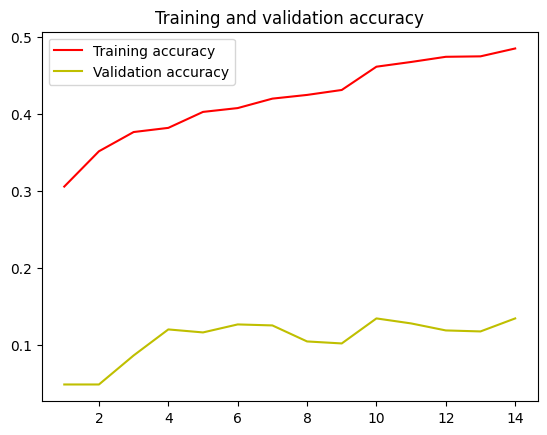

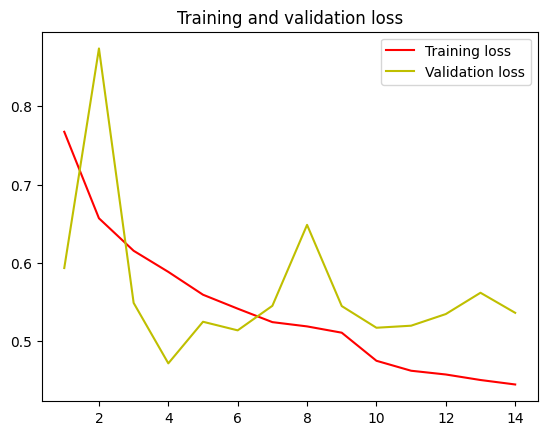

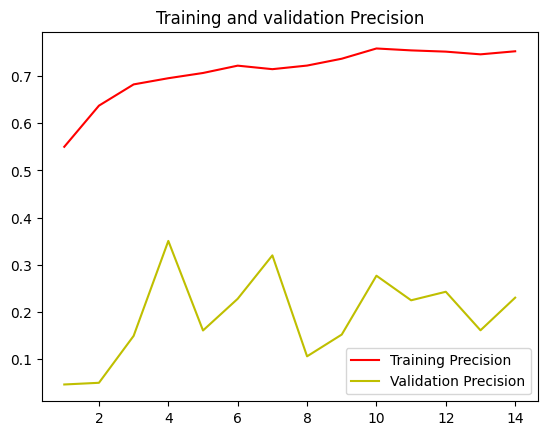

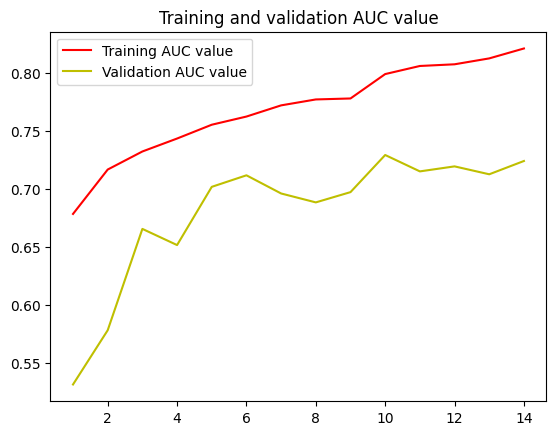

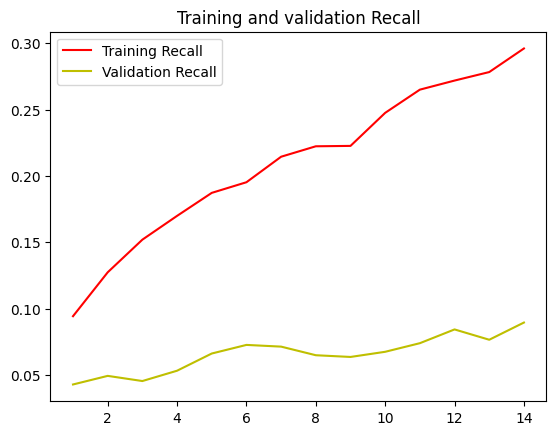

<Figure size 640x480 with 0 Axes>

In [17]:
metrics = [
    ("accuracy", "accuracy"),
    ("loss", "loss"),
    ("precision", "Precision"),
    ("auc", "AUC value"),
    ("recall", "Recall"),
]
epochs = range(1, len(history.history["accuracy"]) + 1)
for key, label in metrics:
    plt.plot(epochs, history.history[key], "r", label=f"Training {label}")
    plt.plot(epochs, history.history[f"val_{key}"], "y", label=f"Validation {label}")
    plt.title(f"Training and validation {label}")
    plt.legend()
    plt.figure()
plt.show()


In [18]:
test_images = []

filename_to_row_idx = {
    fname: idx
    for idx, row in df.iterrows()
    for fname in [row['Left-Fundus'], row['Right-Fundus']]
}

for file_name in testing_source_files:
    if not file_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    idx = filename_to_row_idx.get(file_name)
    true_label = "Unknown"

    if idx is not None:
        row_data = df.iloc[idx]
        for i, label_col in enumerate(config.LABELS):
            if row_data[df.columns[7:][i]] == 1:
                true_label = label_col
                break

    test_images.append((os.path.join(config.TESTING_SOURCE_PATH, file_name), true_label))

print(f"\nPredicting {len(test_images)} files from testing set")
print("Class Mapping:", {i: name for i, name in enumerate(config.LABELS)})

# table header
header = f"| {'File':<30} | {'True Label':<15} | {'Predicted':<15} | {'Pred ID':<8} | {'X ID':<5} | {'Probabilities':<50} |"
separator = f"| {'-'*30} | {'-'*15} | {'-'*15} | {'-'*8} | {'-'*5} | {'-'*50} |"

print(header)
print(separator)

for img_path, true_label in test_images:
    try:
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=config.TARGET_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        classes = model.predict(img_array, batch_size=1, verbose=0)
        pred_idx = np.argmax(classes)
        pred_label = config.LABELS[pred_idx]
        x_idx = np.argmax((classes > 0.05).astype("int32"))

        # table row
        filename = os.path.basename(img_path)
        probs_str = ", ".join([f"{prob:.4f}" for prob in classes[0]])
        row = f"| {filename:<30} | {true_label:<15} | {pred_label:<15} | {pred_idx:<8} | {x_idx:<5} | {probs_str:<50} |"
        print(row)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")



Predicting 1000 files from testing set
Class Mapping: {0: 'N', 1: 'D', 2: 'G', 3: 'C', 4: 'A', 5: 'H', 6: 'M', 7: 'O'}
| File                           | True Label      | Predicted       | Pred ID  | X ID  | Probabilities                                      |
| ------------------------------ | --------------- | --------------- | -------- | ----- | -------------------------------------------------- |
| 1000_left.jpg                  | Unknown         | C               | 3        | 1     | 0.0417, 0.0563, 0.1350, 0.6713, 0.0116, 0.0150, 0.0177, 0.0513 |
| 1000_right.jpg                 | Unknown         | C               | 3        | 1     | 0.0434, 0.0645, 0.1403, 0.6521, 0.0117, 0.0132, 0.0208, 0.0540 |
| 1001_left.jpg                  | Unknown         | C               | 3        | 0     | 0.0558, 0.0432, 0.0879, 0.6664, 0.0043, 0.0059, 0.0624, 0.0741 |
| 1001_right.jpg                 | Unknown         | C               | 3        | 0     | 0.0518, 0.0443, 0.0869, 0.6717, 0.0050,